In [1]:
import numpy as np
import time
import pickle
from scipy import misc
import matplotlib
from matplotlib import cm
import matplotlib.pyplot as plt
from matplotlib.ticker import LinearLocator
import matplotlib.font_manager as font_manager
font = font_manager.FontProperties(style='normal', size=20)
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
%matplotlib inline
# matplotlib.use('Qt5Agg')
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "notebook"
pio.templates["latex"] = go.layout.Template(
    layout=go.Layout(font=dict(family="serif"))
)
pio.templates.default = "plotly+latex"
# Inject MathJax into every fig.show() so $...$ renders as LaTeX
def _show_with_mathjax(self, *args, **kwargs):
    kwargs.setdefault("config", {}).update({"mathjax": "cdn"})
    return pio.show(self, *args, **kwargs)
go.Figure.show = _show_with_mathjax
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import random
import math
import pandas as pd
#import cvxpy as cp
from scipy.optimize import fsolve
from IPython.display import Markdown
# torch.set_default_dtype(torch.float64)
version = 1

/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_90761/2763355602.py:4: DeprecationWarning: scipy.misc is deprecated and will be removed in 2.0.0
  from scipy import misc


# Price impact in the limit order book 

$\inf\left\{\mathbb{E}\left[\sum_{n=0}^{N} \left(D_n+\frac{\kappa}{2}x_n\right)x_n  \right]:\sum_{n=0}^N x_n = X_0\right\}$

$\inf\left\{\mathbb{E}\left[\sum_{n=0}^{N-1} \left(D_n+\frac{\kappa}{2}x_n\right)x_n  + \left(D_N+\frac{\kappa}{2}R_N\right)R_N\right]:x_0,...,x_N-1 \right\}$

$
\begin{cases}
R_{n+1} = R_{n} - x_n & R_0 = X_0\\
D_{n+1} = e^{-\rho\Delta t}\left(D_n + \kappa x_n\right) & D_0 = 0
\end{cases}
$


$V(t_m,D,R) = \inf\left\{\mathbb{E}\left[\sum_{n=m}^{N-1} \left(D_n+\frac{\kappa}{2}x_n\right)x_n  + \left(D_N+\frac{\kappa}{2}R_N\right)R_N\right]:x_m,...,x_N-1\right\}$


- DPP:
$V(t_n,D,R) = \inf\left\{\mathbb{E}\left[\left(D+\frac{\kappa}{2}x\right)x  + V\left(t_{n+1},e^{-\rho\Delta t}(D + \kappa x),R-x\right) \right]:x \right\}$


$V(T,D,R) = \left(D_N+\frac{\kappa}{2}R_N\right)R_N$

$V\left(t_{n+1},D,R\right)=A_{n+1} DR + B_{n+1}R^2 +C_{n+1}D^2$

$$
\begin{split}
V\left(t_{n+1},e^{-\rho\Delta t}(D + \kappa x),R-x\right) &= A_{n+1} e^{-\rho\Delta t}(D + \kappa x)(R-x) + B_{n+1}(R-x)^2 +C_{n+1}e^{-2\rho\Delta t}(D + \kappa x)^2\\
& = A_{n+1} e^{-\rho\Delta t}(DR + (\kappa R - D)x - \kappa x^2) + B_{n+1}(R^2-2xR+x^2) + C_{n+1}e^{-2\rho\Delta t}(D^2+2\kappa D x + \kappa^2 x^2)\\
& = A_{n+1} e^{-\rho\Delta t}DR + B_{n+1}R^2 + C_{n+1}e^{-2\rho\Delta t}D^2 + \left((A_{n+1} e^{-\rho\Delta t}\kappa -2B_{n+1}) R + (-A_{n+1} e^{-\rho\Delta t}+2\kappa C_{n+1}e^{-2\rho\Delta t}) D \right)x + (-A_{n+1} e^{-\rho\Delta t}\kappa + B_{n+1})x^2
\end{split}
$$

$$
\begin{split}
\left(D+\frac{\kappa}{2}x\right)x + V\left(t_{n+1},e^{-\rho\Delta t}(D + \kappa x),R-x\right) &= A_{n+1} e^{-\rho\Delta t}DR + B_{n+1}R^2 + C_{n+1}e^{-2\rho\Delta t}D^2 + \left((A_{n+1} e^{-\rho\Delta t}\kappa -2B_{n+1}) R + (-A_{n+1} e^{-\rho\Delta t}+2\kappa C_{n+1}e^{-2\rho\Delta t}+1) D \right)x \\
&~~~~+ \left(-A_{n+1} e^{-\rho\Delta t}\kappa + B_{n+1}+\frac{\kappa}{2}+C_{n+1}e^{-2\rho\Delta t}\kappa^2\right)x^2
\end{split}
$$

$x^*=-\frac12\dfrac{(A_{n+1} e^{-\rho\Delta t}\kappa -2B_{n+1}) R + (-A_{n+1} e^{-\rho\Delta t}+2\kappa C_{n+1}e^{-2\rho\Delta t}+1) D}{-A_{n+1} e^{-\rho\Delta t}\kappa + B_{n+1}+\frac{\kappa}{2}+C_{n+1}e^{-2\rho\Delta t}\kappa^2}$


$-\frac14\dfrac{\left((A_{n+1} e^{-\rho\Delta t}\kappa -2B_{n+1}) R + (-A_{n+1} e^{-\rho\Delta t}+2\kappa C_{n+1}e^{-2\rho\Delta t}+1) D\right)^2}{-A_{n+1} e^{-\rho\Delta t}\kappa + B_{n+1}+\frac{\kappa}{2}+C_{n+1}e^{-2\rho\Delta t}\kappa^2}$



$$
\begin{split}
\inf_{x} \left(D+\frac{\kappa}{2}x\right)x + V\left(t_{n+1},e^{-\rho\Delta t}(D + \kappa x),R-x\right)  =  A_{n+1} e^{-\rho\Delta t}DR + B_{n+1}R^2 + C_{n+1}e^{-2\rho\Delta t}D^2 -\frac14\dfrac{\left((A_{n+1} e^{-\rho\Delta t}\kappa -2B_{n+1}) R + (-A_{n+1} e^{-\rho\Delta t}+2\kappa C_{n+1}e^{-2\rho\Delta t}+1) D\right)^2}{-A_{n+1} e^{-\rho\Delta t}\kappa + B_{n+1}+\frac{\kappa}{2}+C_{n+1}e^{-2\rho\Delta t}\kappa^2}
\end{split}
$$

# Parameters


In [2]:
lob_params = {
    'T':1,#time horizon
    'mu':.3,
    'gamma':.0,#permanent price impact zero
    'kappa':0.05,#temporary price impact (mean)
    'rho':2,#resilience rate (mean)
    'sigma':.03,#volatility
    'mu':.3,#drift
    'A0':0.,# initial asset price
    'initial_balance':1e3,# initial balance
    'dim':5,# dimension of the state space (time, D, R, kappa, rho)
    'alpha':1.1,
    'theta_kappa':1,# mean-reversion speed for kappa
    'sigma_kappa':0.0283,# volatility of kappa
    'theta_rho':1,# mean-reversion speed for rho
    'sigma_rho':0.7,# volatility of rho
}
approx_params = {
    'num_trajectories': 300,#  number of simulated trajectories
    'num_epochs': 5000, # number of epochs for training
    'num_time_steps': 10, # number of time steps in each trajectory
    'num_neurons': 8,# number of neurons in the hidden layers
    'num_fine_steps': 100,# number of fine steps within one coarse interval
}
approx_params_fine = {
    'num_trajectories_interval': 100,# trajectories per interval
    'num_trajectories_comp': 200,# complete trajectories from t=0 to t=T
    'num_epochs': 5000, # number of epochs for training
    'num_time_steps': 10, # number of time steps in each trajectory
    'num_neurons': 8,# number of neurons in the hidden layers
}


# Coarse PGM

## Neural net for trading

In [3]:
#NN for trading strategy
class trade_net(nn.Module): 
    def __init__(self,params):
        self.dim = params.get('dim', 5)
        self.num_neurons = params['num_neurons']
        super(trade_net, self).__init__()
        self.linear_stack = nn.Sequential(
            nn.Linear(self.dim, self.num_neurons),
            torch.nn.ReLU(),
            nn.Linear(self.num_neurons, self.num_neurons),
            torch.nn.ReLU(),
            nn.Linear(self.num_neurons,1),
        )
    def forward(self, x):
        logits = self.linear_stack(x)
        return logits#.reshape([dim,dim])      

## Neural net for value function 

In [4]:
#NN value function
class value_fnc(nn.Module): 
    def __init__(self,params):
        self.dim = params.get('dim', 5)
        self.num_neurons = params['num_neurons']
        super(value_fnc, self).__init__()
        self.linear_stack = nn.Sequential(
            nn.Linear(self.dim, self.num_neurons),
            torch.nn.ReLU(),
            nn.Linear(self.num_neurons, self.num_neurons),
            torch.nn.ReLU(),
            nn.Linear(self.num_neurons, self.num_neurons),
            torch.nn.ReLU(),
            nn.Linear(self.num_neurons, self.num_neurons),
            torch.nn.ReLU(),
            nn.Linear(self.num_neurons, self.num_neurons),
            torch.nn.ReLU(),
            nn.Linear(self.num_neurons, self.num_neurons),
            torch.nn.ReLU(),
            nn.Linear(self.num_neurons,1),
        )
    def forward(self, x):
        logits = self.linear_stack(x)
        return logits#.reshape([dim,dim])      

In [5]:
class optimal_execution(object):
    def __init__(self,lob_params,approx_params):
        self.epoch = 0
        self.loss_epoch=[]
        self.M = approx_params['num_trajectories']
        self.N = approx_params['num_time_steps']
        self.dim = approx_params['num_neurons']
        self.state_dim = lob_params['dim']
        self.T = lob_params['T']
        self.sigma = lob_params['sigma']
        self.mu = lob_params['mu']
        self.A0 =lob_params['A0'] #initial fundamental price
        self.gamma = lob_params['gamma'] # permanent price impact
        self.kappa = lob_params['kappa'] #price impact coeff (mean)
        self.rho = lob_params['rho'] #resilience (mean)
        self.X0 = lob_params['initial_balance'] #initial balance
        self.neuron_model_psi = approx_params['num_neurons']
        self.delta = self.T/self.N
        self.alpha = lob_params['alpha']
        self.theta_kappa = lob_params['theta_kappa']
        self.sigma_kappa = lob_params['sigma_kappa']
        self.theta_rho = lob_params['theta_rho']
        self.sigma_rho = lob_params['sigma_rho']
        nn_params = {**approx_params, 'dim': self.state_dim}
        self.trade_size = trade_net(nn_params)
        self.V = value_fnc(nn_params)
        t=torch.zeros([self.M,1])
        R=self.X0*0.9+(self.X0*1.1-self.X0*0.9)*torch.rand(self.M,1)
        D=torch.cat([torch.zeros([int(self.M/2),1]),
                     torch.rand([self.M-int(self.M/2),1])*self.X0*0.2*self.kappa], dim=0)
        kappa_std = self.sigma_kappa / np.sqrt(2 * self.theta_kappa)
        rho_std = self.sigma_rho / np.sqrt(2 * self.theta_rho)
        kappa0 = (self.kappa + kappa_std * torch.randn(self.M, 1)).clamp(min=1e-4)
        rho0 = (self.rho + rho_std * torch.randn(self.M, 1)).clamp(min=1e-4)
        self.kappa_paths = torch.zeros(self.M, self.N + 1)
        self.rho_paths = torch.zeros(self.M, self.N + 1)
        self.kappa_paths[:, 0] = kappa0.squeeze()
        self.rho_paths[:, 0] = rho0.squeeze()
        sqrt_delta = np.sqrt(self.delta)
        for n in range(self.N):
            self.kappa_paths[:, n+1] = (self.kappa_paths[:, n]
                + self.theta_kappa * (self.kappa - self.kappa_paths[:, n]) * self.delta
                + self.sigma_kappa * sqrt_delta * torch.randn(self.M)).clamp(min=1e-4)
            self.rho_paths[:, n+1] = (self.rho_paths[:, n]
                + self.theta_rho * (self.rho - self.rho_paths[:, n]) * self.delta
                + self.sigma_rho * sqrt_delta * torch.randn(self.M)).clamp(min=1e-4)
        self.x=torch.cat((t,D,R,kappa0,rho0),dim=1)# initial state: (time, D, R, kappa, rho)
        self.trained = False
        self.exit_dict = lob_params.copy() | approx_params.copy()

    def _gen_paths(self, M):
        """Generate fresh kappa/rho paths for M trajectories."""
        kappa_std = self.sigma_kappa / np.sqrt(2 * self.theta_kappa)
        rho_std = self.sigma_rho / np.sqrt(2 * self.theta_rho)
        self.kappa_paths = torch.zeros(M, self.N + 1)
        self.rho_paths = torch.zeros(M, self.N + 1)
        self.kappa_paths[:, 0] = (self.kappa + kappa_std * torch.randn(M)).clamp(min=1e-4)
        self.rho_paths[:, 0] = (self.rho + rho_std * torch.randn(M)).clamp(min=1e-4)
        sqrt_delta = np.sqrt(self.delta)
        for n in range(self.N):
            self.kappa_paths[:, n+1] = (self.kappa_paths[:, n]
                + self.theta_kappa * (self.kappa - self.kappa_paths[:, n]) * self.delta
                + self.sigma_kappa * sqrt_delta * torch.randn(M)).clamp(min=1e-4)
            self.rho_paths[:, n+1] = (self.rho_paths[:, n]
                + self.theta_rho * (self.rho - self.rho_paths[:, n]) * self.delta
                + self.sigma_rho * sqrt_delta * torch.randn(M)).clamp(min=1e-4)

    def update(self,x,psi):
        n = torch.round(x[:,0] / self.delta).long().clamp(max=self.N-1)
        t=(x[:,0]+self.delta)
        kap = x[:,3]
        rho_val = x[:,4]
        D = (x[:,1]+kap*torch.pow(torch.abs(psi),self.alpha)*torch.sign(psi))*torch.exp(-rho_val*self.delta)
        R= x[:,2]-psi
        kap_next = self.kappa_paths[torch.arange(x.shape[0]), n+1]
        rho_next = self.rho_paths[torch.arange(x.shape[0]), n+1]
        up=torch.cat((t.unsqueeze(1),D.unsqueeze(1),R.unsqueeze(1),kap_next.unsqueeze(1),rho_next.unsqueeze(1)),dim=1)
        return up

    def step_cost(self,x,psi):
        kap = x[:,3]
        loss=(x[:,1]+(kap/2.0)*torch.pow(torch.abs(psi),self.alpha)*torch.sign(psi))*psi
        return loss

    def unit(self,x):
        psi=self.trade_size(x).squeeze(1)
        loss=self.step_cost(x,psi)
        upd=self.update(x,psi)
        return psi, loss, upd

    def cost(self,x):
        M_batch = x.shape[0]
        if self.kappa_paths.shape[0] != M_batch:
            self._gen_paths(M_batch)
        k0 = torch.round(x[:,0] / self.delta).long()  # step index per row, robust to float drift
        cost=torch.zeros(M_batch,self.N+1)
        psi=torch.zeros(M_batch,self.N)
        u=x
        for i in range(self.N+1):
            active = (i >= k0)  # integer comparison, no floating-point tolerance needed
            active3 = active.unsqueeze(1).expand_as(u)
            if(i!=self.N):
                psi_run,loss_run,u_run = self.unit(u)
                cost[:,i] = torch.where(active, loss_run, torch.zeros_like(loss_run))
                psi[:,i] = psi_run
                u = torch.where(active3, u_run, u)  # freeze inactive rows
            else:
                step_c = self.step_cost(u,u[:,2])
                cost[:,i] = torch.where(active, step_c, torch.zeros_like(step_c))
        cost=torch.sum(cost,dim=1)
        return cost
    
    def train(self, lr, err, num_epochs, train_value=True):
        start=time.time()
        epoch=self.epoch
        L_=0.1
        optimizer = optim.Adam(self.trade_size.parameters(), lr)
        L=100000
        while (np.abs(L_-L)/np.abs(L_)>err) &  (epoch <= num_epochs):
            t0 = time.time()
            optimizer.zero_grad()
            cost=self.cost(self.x)
            loss = torch.mean(cost) 
            loss.backward()
            optimizer.step()
            L = loss.clone().detach().numpy()
            self.loss_epoch.append(L)
            if epoch>0:
                L_ = self.loss_epoch[epoch-1]
            if (epoch % int(num_epochs/5)== int(num_epochs/5)-1) | (epoch == 0):
                print("At epoch {:,} the mean cost is {:.10E}.  Epoch training time = {:.2E} ms".format(epoch+1,loss.detach(),1000*(time.time()-t0)))            
            epoch=epoch+1
        end=time.time()
        print('time elapsed = {:.2e} ms'.format((end-start)*1000))
        print("Relative change in loss = %{:.7E} , last epoch = {}.".format((100*np.abs(L_-L)/np.abs(L_)),epoch+1))        
     
        self.epoch = epoch
        self.exit_dict['loss_log'] = self.loss_epoch
        self.exit_dict['last_epoch'] = epoch-1
        self.exit_dict['relative change in loss'] = (np.abs(L_-L)/np.abs(L_))
        self.exit_dict['execution_time'] = (end-start)*1000
        
        self.trained = True

        if not train_value:
            self.exit_dict['optimal_strategy'] = self.trade_size
            return

        # ---- Level 2: retrain trade_size on rectangle-sampled (D, R) ----
        self.gen_data()  # get Level 1 x_data to find bounding boxes
        x_rect_list = []
        for n in range(self.N + 1):
            t_n = n * self.delta
            mask = torch.abs(self.x_data[:, 0] - t_n) < 1e-6
            D_on = self.x_data[mask, 1]
            R_on = self.x_data[mask, 2]
            D_min, D_max = D_on.min().item(), D_on.max().item()
            R_min, R_max = R_on.min().item(), R_on.max().item()
            D_samp = D_min + (D_max - D_min) * torch.rand(self.M, 1)
            R_samp = R_min + (R_max - R_min) * torch.rand(self.M, 1)
            t_samp = torch.full((self.M, 1), t_n)
            kap_on = self.x_data[mask, 3]
            rho_on = self.x_data[mask, 4]
            kap_samp = kap_on.min() + (kap_on.max() - kap_on.min()) * torch.rand(self.M, 1)
            rho_samp = rho_on.min() + (rho_on.max() - rho_on.min()) * torch.rand(self.M, 1)
            x_rect_list.append(torch.cat((t_samp, D_samp, R_samp, kap_samp, rho_samp), dim=1))
        x_rect = torch.cat(x_rect_list, dim=0)
        M_rect = x_rect.shape[0]
        self._gen_paths(M_rect)

        print("Level 2: retraining trade_size on {:,} rectangle-sampled states...".format(M_rect))
        optimizer2 = optim.Adam(self.trade_size.parameters(), lr)
        epoch2 = 0
        L2_ = 0.1
        L2 = 100000.0
        loss2_log = []
        while (np.abs(L2_ - L2) / np.abs(L2_) > err) and (epoch2 <= num_epochs):
            t0 = time.time()
            optimizer2.zero_grad()
            cost2 = self.cost(x_rect)
            loss2 = torch.mean(cost2)
            loss2.backward()
            optimizer2.step()
            L2 = loss2.clone().detach().numpy()
            loss2_log.append(L2)
            if epoch2 > 0:
                L2_ = loss2_log[epoch2 - 1]
            if (epoch2 % max(1, int(num_epochs/5)) == max(1, int(num_epochs/5))-1) or (epoch2 == 0):
                print("  [L2] epoch {:,}  mean cost = {:.10E}  ({:.2E} ms)".format(epoch2+1, float(loss2.detach()), 1000*(time.time()-t0)))
            epoch2 += 1
        print("Level 2 training done ({:,} epochs).".format(epoch2))

        self.exit_dict['optimal_strategy'] = self.trade_size
        self.value()#  Must be after the line above.  gen_data is rerun inside value().
        self.exit_dict['data'] = [self.x_data,self.y_data]#  Must be after the line above.
        self.exit_dict['value'] = self.V
        # self.exit_dict['value_fat'] = self.V_fat

        
    def gen_data(self):
        if self.trained:
            # --- Level 2: rectangle-sampled (D, R) at each time step, starting points only ---
            # First, do a standard rollout to find bounding boxes
            cost=torch.zeros(self.M,self.N+1)
            psi=torch.zeros(self.M,self.N)
            u=self.x
            traj_data = u
            for i in range(self.N+1):
                if(i!=self.N):
                    if i >0:
                        traj_data = torch.cat((traj_data,u),axis=0)
                    psi_run,loss_run,u_run=self.unit(u) 
                    cost[:,i]=loss_run
                    psi[:,i]=psi_run
                    u=u_run
                else:
                    cost[:,i]=self.step_cost(u,u[:,2])
                    traj_data = torch.cat((traj_data,u),axis=0)

            # Generate rectangle-sampled starting points and their cost-to-go
            self.x_data = torch.empty(0, 5)
            self.y_data = torch.empty(0, 1)
            for n in range(self.N + 1):
                t_n = n * self.delta
                mask = torch.abs(traj_data[:, 0] - t_n) < 1e-6
                D_on = traj_data[mask, 1]
                R_on = traj_data[mask, 2]
                D_min, D_max = D_on.min().item(), D_on.max().item()
                R_min, R_max = R_on.min().item(), R_on.max().item()
                D_samp = D_min + (D_max - D_min) * torch.rand(self.M, 1)
                R_samp = R_min + (R_max - R_min) * torch.rand(self.M, 1)
                t_samp = torch.full((self.M, 1), t_n)
                kap_on = traj_data[mask, 3]
                rho_on = traj_data[mask, 4]
                kap_samp = kap_on.min() + (kap_on.max() - kap_on.min()) * torch.rand(self.M, 1)
                rho_samp = rho_on.min() + (rho_on.max() - rho_on.min()) * torch.rand(self.M, 1)
                x_start = torch.cat((t_samp, D_samp, R_samp, kap_samp, rho_samp), dim=1)
                with torch.no_grad():
                    self._gen_paths(self.M)
                    y_start = self.cost(x_start).unsqueeze(-1)
                self.x_data = torch.cat((self.x_data, x_start), dim=0)
                self.y_data = torch.cat((self.y_data, y_start), dim=0)

            r = torch.randperm(self.x_data.shape[0])
            self.x_data = self.x_data[r,:].clone().detach()
            self.y_data = self.y_data[r,:].clone().detach()  
            self.exit_dict['data'] = self.x_data

            # # --- fat rollout from perturbed self.x_data (all time steps) ---
            # epsilon = 0.5
            # noise_init = torch.zeros_like(self.x_data)
            # noise_init[:, 1:] = torch.randn_like(self.x_data[:, 1:])
            # noise_init[self.x_data[:, 0] == 0] = 0
            # x_fat_init = self.x_data * (1 + epsilon * noise_init)
            # x_fat_init[:, 1:] = x_fat_init[:, 1:].clamp(min=0)
            # M_fat = x_fat_init.shape[0]
            # k0 = torch.round(x_fat_init[:, 0] / self.delta).long()
            # cost_fat = torch.zeros(M_fat, self.N+1)
            # u_fat = x_fat_init
            # self._x_data_fat = u_fat
            # for i in range(self.N+1):
            # active = (i >= k0)
            # active3 = active.unsqueeze(1).expand_as(u_fat)
            # if i != self.N:
            # if i > 0:
            # self._x_data_fat = torch.cat((self._x_data_fat, u_fat), axis=0)
            # psi_run, loss_run, u_run = self.unit(u_fat)
            # cost_fat[:, i] = torch.where(active, loss_run, torch.zeros_like(loss_run))
            # u_fat = torch.where(active3, u_run, u_fat)
            # else:
            # step_c = self.step_cost(u_fat, u_fat[:, 2])
            # cost_fat[:, i] = torch.where(active, step_c, torch.zeros_like(step_c))
            # self._x_data_fat = torch.cat((self._x_data_fat, u_fat), axis=0)
            # self.y_data_fat = torch.sum(cost_fat, dim=1).unsqueeze(-1)
            # for i in range(self.N):
            # self.y_data_fat = torch.cat((self.y_data_fat, torch.sum(cost_fat[:, i+1:], dim=1).unsqueeze(-1)), axis=0)
            # r_fat = torch.randperm(self._x_data_fat.shape[0])
            # self._x_data_fat = self._x_data_fat[r_fat].clone().detach()
            # self.y_data_fat = self.y_data_fat[r_fat].clone().detach()
        else:
            self.train(8e-3,1e-7,3000)
            self.gen_data()        
            
    def value(self):
        self.V     = value_fnc({'num_neurons': self.dim, 'dim': self.state_dim})  # fresh networks each call
        # self.V_fat = value_fnc({'num_neurons': self.dim})
        self.gen_data()
        scale   = self.kappa * self.X0 ** 2
        x_scale = torch.tensor([self.T, self.kappa * self.X0 / self.N, self.X0, self.kappa, self.rho])

        # --- train V on x_data / y_data (mini-batch SGD) ---
        x_norm = self.x_data / x_scale
        y_norm = self.y_data / scale
        lr = 8e-3
        num_epochs = 1000
        batch_size = 256
        err = 1e-5
        optimizer = optim.Adam(self.V.parameters(), lr)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=200, factor=0.5)
        mse = nn.MSELoss()
        n_samples = x_norm.shape[0]
        epoch_loss_prev = torch.tensor([1.0])
        print("Building value function (mini-batch, batch_size={})...".format(batch_size))
        t_start = time.time()
        for epoch in range(num_epochs):
            perm = torch.randperm(n_samples)
            x_shuf = x_norm[perm]
            y_shuf = y_norm[perm]
            batch_losses = []
            for b in range(0, n_samples, batch_size):
                xb = x_shuf[b:b+batch_size]
                yb = y_shuf[b:b+batch_size]
                optimizer.zero_grad()
                loss = mse(self.V(xb), yb)
                loss.backward()
                optimizer.step()
                batch_losses.append(loss.detach())
            epoch_loss = torch.stack(batch_losses).mean()
            scheduler.step(epoch_loss)
            if epoch > 0:
                rel_change = (torch.abs(epoch_loss_prev - epoch_loss) / torch.abs(epoch_loss_prev)).item()
                if rel_change < err:
                    print("Converged at epoch {:,}  rel. change = {:.3E}".format(epoch+1, rel_change))
                    break
            if epoch % 500 == 499 or epoch == 0:
                rc = (torch.abs(epoch_loss_prev - epoch_loss) / torch.abs(epoch_loss_prev)).item() if epoch > 0 else float('inf')
                print("Epoch {:,}  MSE = {:.3E}  rel. change = {:.3E}  lr = {:.1E}".format(epoch+1, epoch_loss.item(), rc, optimizer.param_groups[0]['lr']))
            epoch_loss_prev = epoch_loss
        t_elapsed = time.time() - t_start
        print("Value function training time: {:.2f} s  ({} epochs)".format(t_elapsed, epoch+1))
        with torch.no_grad():
            self.V.linear_stack[-1].weight.mul_(scale)
            self.V.linear_stack[-1].bias.mul_(scale)
            self.V.linear_stack[0].weight.data.div_(x_scale.unsqueeze(0))

        # # --- train V_fat on _x_data_fat / y_data_fat ---
        # x_fat_norm = self._x_data_fat / x_scale
        # y_fat_norm = self.y_data_fat / scale
        # epoch = 0
        # loss_epoch = []
        # L_   = torch.tensor([1.])
        # loss = torch.tensor([1000.])
        # optimizer = optim.Adam(self.V_fat.parameters(), lr)
        # print("Building fat value function...")
        # t_start = time.time()
        # while (torch.abs(L_ - loss) / torch.abs(L_) > err) and (epoch <= num_epochs):
        # optimizer.zero_grad()
        # loss = mse(self.V_fat(x_fat_norm), y_fat_norm)
        # loss.backward()
        # optimizer.step()
        # loss_epoch.append(loss)
        # if epoch > 0:
        # L_ = loss_epoch[epoch - 1]
        # epoch += 1
        # if epoch % 500 == 499:
        # print("Epoch {:,}  rel. change = {:.3E}".format(epoch, (torch.abs(L_ - loss) / torch.abs(L_)).item()))
        # t_elapsed = time.time() - t_start
        # print("Fat value function training time: {:.2f} s  ({} epochs)".format(t_elapsed, epoch))
        # print("Final rel. change in MSE: {:.3E}".format((torch.abs(L_ - loss) / torch.abs(L_)).item()))
        # with torch.no_grad():
        # self.V_fat.linear_stack[-1].weight.mul_(scale)
        # self.V_fat.linear_stack[-1].bias.mul_(scale)
        # self.V_fat.linear_stack[0].weight.data.div_(x_scale.unsqueeze(0))

        


    # def __call__(self,x_init):
    #     t = torch.tensor([i*self.delta for i in range(self.N+1)])
    #     for i in range(x_init.shape[0]):
    #         if i==0:
    #             trade = ((1-(torch.where(t==0.0*self.delta,0,1)*torch.where(t==self.N*self.delta,0,1))*self.a)*x_init[i]/((self.N-1)*(1-self.a)+2)).unsqueeze(0)
    #         else:
    #             trade = torch.cat((trade,((1-(torch.where(t==0.0*self.delta,0,1)*torch.where(t==self.N*self.delta,0,1))*self.a)*x_init[i]/((self.N-1)*(1-self.a)+2)).unsqueeze(0)),axis=0)
    #     return trade

In [6]:
oe = optimal_execution(lob_params, approx_params)
print('Created fresh oe for v3 two-level training.')

Created fresh oe for v3 two-level training.


In [7]:
t_start = time.time()
oe.train(8e-3, 1e-9, 3000)
t_elapsed_coarse = time.time() - t_start
print(f"\nTotal wall-clock time: {t_elapsed_coarse:.2f} s  ({t_elapsed_coarse/60:.2f} min)")


At epoch 1 the mean cost is 2.2082611328E+04.  Epoch training time = 2.19E+02 ms


At epoch 600 the mean cost is 2.1699808594E+04.  Epoch training time = 6.85E+00 ms


time elapsed = 6.58e+03 ms
Relative change in loss = %0.0000000E+00 , last epoch = 708.
Level 2: retraining trade_size on 3,300 rectangle-sampled states...
  [L2] epoch 1  mean cost = 1.5703583008E+04  (1.94E+01 ms)


  [L2] epoch 600  mean cost = 1.5532039062E+04  (1.57E+01 ms)


  [L2] epoch 1,200  mean cost = 1.5073738281E+04  (1.61E+01 ms)


  [L2] epoch 1,800  mean cost = 5.6036398438E+04  (7.72E+00 ms)


  [L2] epoch 2,400  mean cost = 2.8959656250E+04  (7.64E+00 ms)


  [L2] epoch 3,000  mean cost = 2.5926837891E+04  (8.24E+00 ms)
Level 2 training done (3,001 epochs).
Building value function (mini-batch, batch_size=256)...
Epoch 1  MSE = 6.822E-01  rel. change = INF  lr = 8.0E-03


Converged at epoch 170  rel. change = 2.546E-06
Value function training time: 0.85 s  (170 epochs)

Total wall-clock time: 44.76 s  (0.75 min)


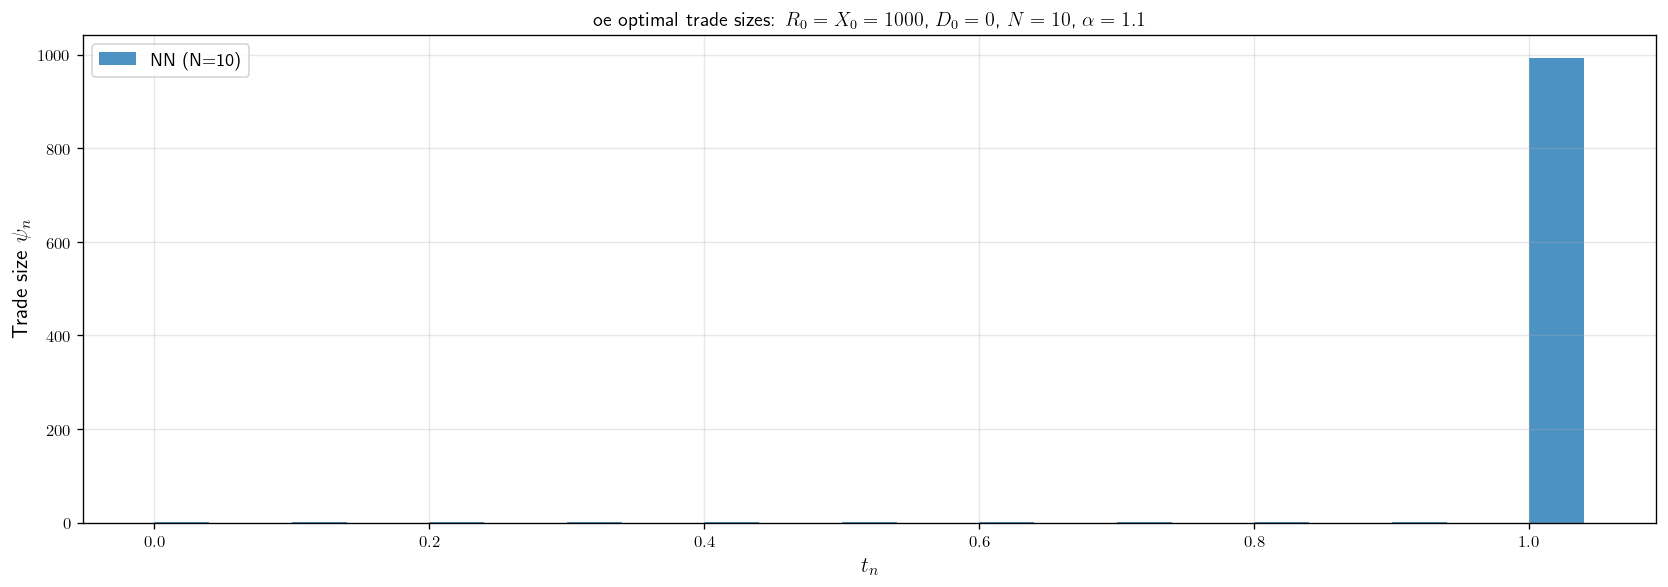

In [8]:
# Trade size along optimal trajectory starting at (0, 0, X0, kappa_mean, rho_mean)
u = torch.tensor([[0.0, 0.0, float(oe.X0), oe.kappa, oe.rho]])
psi_oe, t_oe = [], []
for n in range(oe.N):
    t_oe.append(n * oe.delta)
    with torch.no_grad():
        psi = oe.trade_size(u).squeeze().item()
    psi_oe.append(psi)
    u = oe.update(u, torch.tensor([psi]))
t_oe.append(oe.N * oe.delta)
psi_oe.append(u[0, 2].item())

t_oe = np.array(t_oe)
bar_w = oe.delta * 0.4

fig, ax = plt.subplots(figsize=(14, 5), dpi=120)
ax.bar(t_oe, psi_oe, width=bar_w, align='edge', alpha=0.8, label='NN (N=10)')
ax.set_xlabel(r'$t_n$', fontsize=13)
ax.set_ylabel(r'Trade size $\psi_n$', fontsize=13)
ax.set_title(f'oe optimal trade sizes: $R_0=X_0={int(oe.X0)}$, $D_0=0$, $N={oe.N}$, $\\alpha={oe.alpha}$', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(f'v7_alpha{oe.alpha}_bar_chart_oe.png', dpi=150, bbox_inches='tight')
plt.show()


In [9]:
# value() is now called inside train(), no separate call needed

In [10]:
# if not hasattr(oe, 'V_fat'):
#     oe.value()

In [11]:
# # Compare V and V_fat on oe.x_data
# with torch.no_grad():
#     v_pred     = oe.V(oe.x_data).squeeze().numpy()
#     v_fat_pred = oe.V_fat(oe.x_data).squeeze().numpy()

# x_np  = oe.x_data.numpy()
# t_np  = x_np[:, 0]
# D_np  = x_np[:, 1]
# R_np  = x_np[:, 2]
# n_idx = np.round(t_np / oe.delta).astype(int).clip(0, oe.N)
# v_cf  = np.zeros(len(t_np))
# for n in range(oe.N + 1):
#     mask = n_idx == n
#     if mask.any():
#         v_cf[mask] = oe.cf.value_function(n, D_np[mask], R_np[mask])

# rel_err_V     = np.mean(np.abs(v_cf - v_pred))     / np.mean(np.abs(v_cf)) * 100
# rel_err_V_fat = np.mean(np.abs(v_cf - v_fat_pred)) / np.mean(np.abs(v_cf)) * 100
# print(f"Relative L1 error  V     vs CF: {rel_err_V:.3f}%")
# print(f"Relative L1 error  V_fat vs CF: {rel_err_V_fat:.3f}%")

# fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=110)

# axes[0].scatter(v_cf, v_pred,     s=3, alpha=0.4, label=r'$V$')
# axes[0].scatter(v_cf, v_fat_pred, s=3, alpha=0.4, label=r'$V_{\rm fat}$')
# lim = [min(v_cf.min(), v_pred.min(), v_fat_pred.min()),
#        max(v_cf.max(), v_pred.max(), v_fat_pred.max())]
# axes[0].plot(lim, lim, 'k--', lw=1)
# axes[0].set_xlabel(r'$V_{\rm CF}$', fontsize=13)
# axes[0].set_ylabel(r'Predicted $V$', fontsize=13)
# axes[0].set_title(r'$V$ and $V_{\rm fat}$ vs closed-form on oe.x\_data', fontsize=11)
# axes[0].legend(fontsize=11)
# axes[0].grid(True, alpha=0.3)

# axes[1].scatter(v_pred, v_fat_pred, s=3, alpha=0.4, color='tab:green')
# lim2 = [min(v_pred.min(), v_fat_pred.min()), max(v_pred.max(), v_fat_pred.max())]
# axes[1].plot(lim2, lim2, 'k--', lw=1, label='identity')
# axes[1].set_xlabel(r'$V$', fontsize=13)
# axes[1].set_ylabel(r'$V_{\rm fat}$', fontsize=13)
# axes[1].set_title(r'$V_{\rm fat}$ vs $V$ on oe.x\_data', fontsize=11)
# axes[1].legend(fontsize=11)
# axes[1].grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

In [12]:
xy = oe.x_data
z = oe.V(xy)
xyz = torch.cat((xy,z),axis=1).detach().numpy()
np.savetxt('LOB_linear_value_data_v{}.txt'.format(version),xyz[:,1:])
np.savetxt('LOB_linear_value_data_v{}.txt'.format(2),xyz,header='t x y z',comments='')

In [13]:
# X = np.arange(5000, 15000, 25)
# Y = np.arange(25000, 50000, 25)
# X_grid, Y_grid = np.meshgrid(X, Y)
# Z = Y_grid * (X_grid + oe.kappa / 2.0 * Y_grid)
# 
# fig = go.Figure(data=[go.Surface(x=X_grid, y=Y_grid, z=Z, colorscale='RdBu')])
# fig.update_layout(
#     scene=dict(xaxis_title='D', yaxis_title='R', zaxis_title='V'),
#     width=800, height=700
# )
# fig.show()

=== V_NN(T, D, R, kappa, rho) vs exact ===
  Relative L1 error: 142.7462%
  Max absolute error: 75805.2891

=== y_data at t=T vs exact ===
  Relative L1 error: 93.330864%
  Max absolute error: 65358.757812


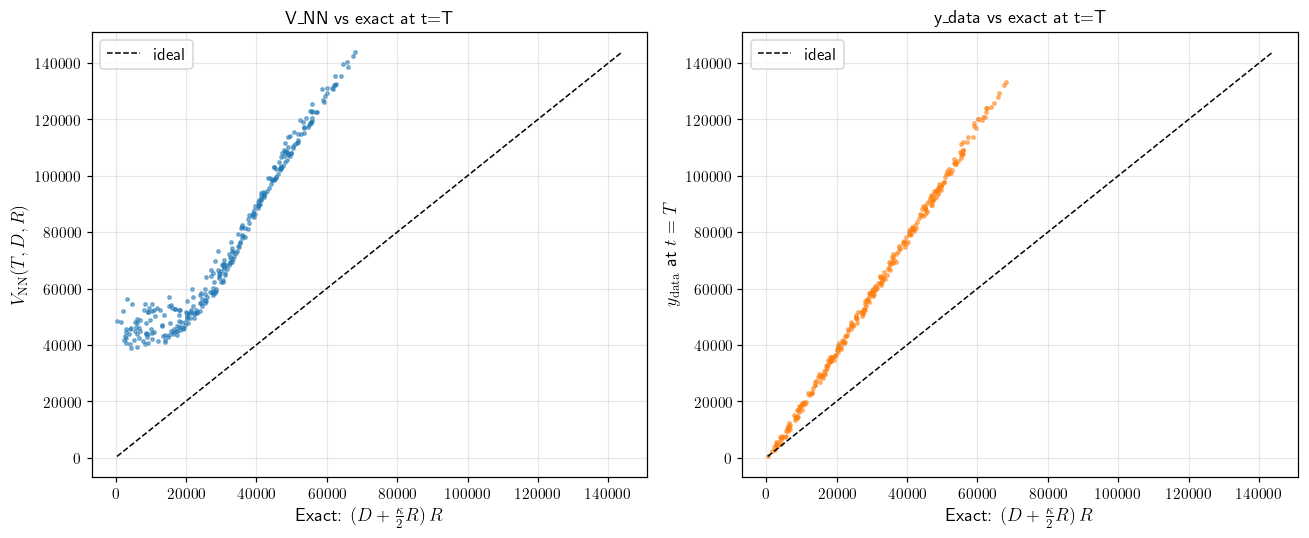

In [14]:
# Sanity check: V(T, D, R, kappa, rho) vs exact terminal cost (D + kappa/2 * R) * R
with torch.no_grad():
    x_T = oe.x_data[torch.abs(oe.x_data[:, 0] - oe.T) < 1e-6]
    D_T = x_T[:, 1]
    R_T = x_T[:, 2]
    kap_T = x_T[:, 3]
    V_nn = oe.V(x_T).squeeze()
    V_exact = (D_T + kap_T / 2.0 * R_T) * R_T

    mask_T = torch.abs(oe.x_data[:, 0] - oe.T) < 1e-6
    y_T = oe.y_data[mask_T].squeeze()
    y_diff = torch.abs(y_T - V_exact)

print("=== V_NN(T, D, R, kappa, rho) vs exact ===")
rel_err_nn = torch.mean(torch.abs(V_nn - V_exact)) / torch.mean(torch.abs(V_exact)) * 100
print(f"  Relative L1 error: {rel_err_nn:.4f}%")
print(f"  Max absolute error: {torch.max(torch.abs(V_nn - V_exact)):.4f}")

print("\n=== y_data at t=T vs exact ===")
rel_err_y = torch.mean(y_diff) / torch.mean(torch.abs(V_exact)) * 100
print(f"  Relative L1 error: {rel_err_y:.6f}%")
print(f"  Max absolute error: {torch.max(y_diff):.6f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=110)
axes[0].scatter(V_exact.numpy(), V_nn.numpy(), s=5, alpha=0.5)
lim = [min(V_exact.min(), V_nn.min()).item(), max(V_exact.max(), V_nn.max()).item()]
axes[0].plot(lim, lim, 'k--', lw=1, label='ideal')
axes[0].set_xlabel(r'Exact: $(D + \frac{\kappa}{2} R)\, R$', fontsize=12)
axes[0].set_ylabel(r'$V_{\mathrm{NN}}(T, D, R)$', fontsize=12)
axes[0].set_title('V_NN vs exact at t=T', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].scatter(V_exact.numpy(), y_T.numpy(), s=5, alpha=0.5, color='tab:orange')
axes[1].plot(lim, lim, 'k--', lw=1, label='ideal')
axes[1].set_xlabel(r'Exact: $(D + \frac{\kappa}{2} R)\, R$', fontsize=12)
axes[1].set_ylabel(r'$y_{\mathrm{data}}$ at $t=T$', fontsize=12)
axes[1].set_title('y_data vs exact at t=T', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [15]:
# # Diagnose degeneracy: D vs R scatter at each time step, and V_nn vs V_cf
# x = oe._x_data_fat
# t_vals = sorted(list(set(x[:,0].numpy())))
# color = plt.cm.rainbow(np.linspace(0, 1, oe.N+1))

# fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=120)

# # Left: (D, R) scatter — should span 2-D if data is rich; collapses to a curve if degenerate
# ax0 = axes[0]
# for i, c in enumerate(color):
#     xy  = x[x[:,0] == t_vals[i]].detach().numpy()
#     ax0.scatter(xy[:,1], xy[:,2], color=c, s=2, alpha=0.5)
# ax0.set_xlabel(r'$D$', fontsize=13)
# ax0.set_ylabel(r'$R$', fontsize=13)
# ax0.set_title(r'$(D, R)$ distribution per time step (rainbow = $t_0 \to t_N$)', fontsize=11)

# # Right: V_nn vs V_cf at each state — perfect match = diagonal line
# ax1 = axes[1]
# for i, c in enumerate(color):
#     xy   = x[x[:,0] == t_vals[i]]
#     pts = xy.detach().numpy()
#     V_nn = oe.V_fat(xy).detach().numpy().squeeze()
#     V_cf = oe.cf.value_function(i, pts[:,1], pts[:,2])
#     ax1.scatter(V_cf, V_nn, color=c, s=2, alpha=0.5)
# vmin = min(ax1.get_xlim()[0], ax1.get_ylim()[0])
# vmax = max(ax1.get_xlim()[1], ax1.get_ylim()[1])
# ax1.plot([vmin, vmax], [vmin, vmax], 'k--', lw=1, label='ideal')
# ax1.set_xlabel(r'$V_{\mathrm{CF}}$', fontsize=13)
# ax1.set_ylabel(r'$V_{\mathrm{NN}}$', fontsize=13)
# ax1.set_title(r'$V_{\mathrm{NN}}$ vs $V_{\mathrm{CF}}$ (rainbow = $t_0 \to t_N$)', fontsize=11)
# ax1.legend(fontsize=11)

# # Print D range per time step
# print("Time step  |  D range              |  R range")
# for i in range(oe.N+1):
#     xy = x[x[:,0] == t_vals[i]].detach().numpy()
#     print(f"  t={t_vals[i]:.2f}   |  D in [{xy[:,1].min():.3f}, {xy[:,1].max():.3f}]  |  R in [{xy[:,2].min():.2f}, {xy[:,2].max():.2f}]")

# plt.tight_layout()
# plt.show()

In [16]:
# # Compare x_data vs _x_data_fat: (D, R) scatter at each time step
# x = oe.x_data
# x_fat = oe._x_data_fat
# t_vals = sorted(set(x[:, 0].numpy()))

# ncols = min(len(t_vals), 6)
# nrows = (len(t_vals) + ncols - 1) // ncols
# fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows), squeeze=False)

# for idx, t in enumerate(t_vals):
#     ax = axes[idx // ncols, idx % ncols]
#     mask     = (x[:, 0] == t)
#     mask_fat = (x_fat[:, 0] == t)
#     ax.scatter(x[mask, 1].numpy(), x[mask, 2].numpy(),
#                s=4, alpha=0.5, label='x_data', zorder=2)
#     ax.scatter(x_fat[mask_fat, 1].numpy(), x_fat[mask_fat, 2].numpy(),
#                s=4, alpha=0.3, label='x_data_fat', zorder=1)
#     ax.set_title(f't = {t:.2f}')
#     ax.set_xlabel('D')
#     ax.set_ylabel('R')
#     if idx == 0:
#         ax.legend(fontsize=9)

# for idx in range(len(t_vals), nrows * ncols):
#     axes[idx // ncols, idx % ncols].set_visible(False)

# plt.suptitle('x_data vs _x_data_fat per time step', fontsize=14, y=1.01)
# plt.tight_layout()
# plt.show()

# Fine-scale PGM

Solve the sub-problem on $[0,\, t_1]$ where $t_1 = T / N_{\text{coarse}}$.

- **Fine steps**: $N_f = 10$, step size $\delta_f = t_1 / N_f = T / (N_{\text{coarse}} \cdot N_f)$
- **Resilience** per fine step: $\alpha_f = e^{-\rho\,\delta_f}$
- **Running cost** (unchanged): $(D + \tfrac{\kappa}{2}\,x)\,x$
- **Terminal cost** at $t_1$: $g(D, R) = \bigl(D + \tfrac{\kappa}{2}\,R\bigr)R$ — the same functional form as $V(T,\cdot)$

In [17]:
class fine_optimal_execution(object):
    """PGM on [0, t_1] with t_1 = T/N_coarse, N_fine fine steps,
    and the terminal cost g(D,R) = (D + kappa/2 * R)*R as the boundary condition."""

    def __init__(self, oe, approx_params_fine, intervals=None, num_fine_steps=10):
        self.M_interval = approx_params_fine['num_trajectories_interval']
        self.M_comp     = approx_params_fine['num_trajectories_comp']
        self.N_coarse   = oe.N
        self.N          = num_fine_steps
        self.T          = oe.T
        self.intervals  = (set(intervals) if intervals is not None else set(range(1, oe.N + 1))) | {1, oe.N}
        self.t_starts   = [(n - 1) * oe.delta for n in self.intervals]
        self.t_ends     = [n * oe.delta for n in self.intervals]
        self.delta      = oe.delta / self.N
        self.kappa      = oe.kappa
        self.rho        = oe.rho
        self.alpha      = oe.alpha
        self.theta_kappa = oe.theta_kappa
        self.sigma_kappa = oe.sigma_kappa
        self.theta_rho  = oe.theta_rho
        self.sigma_rho  = oe.sigma_rho
        self.state_dim  = oe.state_dim
        self.X0         = oe.X0
        self.epoch      = 0
        self.loss_epoch = []
        self.trained    = False
        self.coarse_V   = oe.V
        for p in self.coarse_V.parameters():
            p.requires_grad_(False)

        self.trade_size = trade_net({'num_neurons': oe.dim, 'dim': self.state_dim})
        self.V          = value_fnc({'num_neurons': oe.dim, 'dim': self.state_dim})


        x_list = []
        for t_start in self.t_starts:
            mask = torch.abs(oe.x_data[:, 0] - t_start) < 1e-6
            candidates = oe.x_data[mask]
            D_on = candidates[:, 1]
            R_on = candidates[:, 2]
            kap_on = candidates[:, 3]
            rho_on = candidates[:, 4]
            D_mid = (D_on.min() + D_on.max()) / 2
            R_mid = (R_on.min() + R_on.max()) / 2
            D_half = (D_on.max() - D_on.min()) / 4
            R_half = (R_on.max() - R_on.min()) / 4
            D_samp = D_mid - D_half + 2 * D_half * torch.rand(self.M_interval, 1)
            R_samp = R_mid - R_half + 2 * R_half * torch.rand(self.M_interval, 1)
            kap_samp = kap_on.min() + (kap_on.max() - kap_on.min()) * torch.rand(self.M_interval, 1)
            rho_samp = rho_on.min() + (rho_on.max() - rho_on.min()) * torch.rand(self.M_interval, 1)
            t_samp = torch.full((self.M_interval, 1), t_start)
            x_list.append(torch.cat((t_samp, D_samp, R_samp, kap_samp, rho_samp), dim=1))
        self.x = torch.cat(x_list, dim=0)

        kappa_std = self.sigma_kappa / np.sqrt(2 * self.theta_kappa)
        rho_std = self.sigma_rho / np.sqrt(2 * self.theta_rho)
        t_comp = torch.zeros(self.M_comp, 1)
        D_comp = torch.zeros(self.M_comp, 1)
        R_comp = self.X0 * 0.9 + (self.X0 * 1.1 - self.X0 * 0.9) * torch.rand(self.M_comp, 1)
        kap_comp = (self.kappa + kappa_std * torch.randn(self.M_comp, 1)).clamp(min=1e-4)
        rho_comp = (self.rho + rho_std * torch.randn(self.M_comp, 1)).clamp(min=1e-4)
        self.x_comp = torch.cat((t_comp, D_comp, R_comp, kap_comp, rho_comp), dim=1)
        self.N_total = self.N * self.N_coarse

        self.w_interval = 1.0
        self.w_comp     = 1.0

    # ------------------------------------------------------------------
    def terminal_cost(self, x):
        """Liquidate all remaining inventory: same as optimal_execution."""
        return self.step_cost(x, x[:, 2])

    def update(self, x, psi):
        t = x[:, 0] + self.delta
        kap = x[:, 3]
        rho_val = x[:, 4]
        D = (x[:, 1] + kap * torch.pow(torch.abs(psi), self.alpha) * torch.sign(psi)) * torch.exp(-rho_val * self.delta)
        R = x[:, 2] - psi
        sqrt_delta = np.sqrt(self.delta)
        M = x.shape[0]
        kap_next = (kap + self.theta_kappa * (self.kappa - kap) * self.delta
                    + self.sigma_kappa * sqrt_delta * torch.randn(M)).clamp(min=1e-4)
        rho_next = (rho_val + self.theta_rho * (self.rho - rho_val) * self.delta
                    + self.sigma_rho * sqrt_delta * torch.randn(M)).clamp(min=1e-4)
        return torch.cat((t.unsqueeze(1), D.unsqueeze(1), R.unsqueeze(1), kap_next.unsqueeze(1), rho_next.unsqueeze(1)), dim=1)

    def step_cost(self, x, psi):
        kap = x[:, 3]
        return (x[:, 1] + (kap / 2.0) * torch.pow(torch.abs(psi), self.alpha) * torch.sign(psi)) * psi

    def unit(self, x):
        psi  = self.trade_size(x).squeeze(1)
        loss = self.step_cost(x, psi)
        upd  = self.update(x, psi)
        return psi, loss, upd

    def cost(self, x):
        """Mean cost across intervals plus mean cost of complete trajectories."""
        # --- interval cost (unchanged) ---
        intervals_sorted = sorted(self.intervals)
        interval_means = []
        for i, n_int in enumerate(intervals_sorted):
            u = x[i * self.M_interval : (i + 1) * self.M_interval]
            costs = torch.zeros(self.M_interval, self.N + 1)
            for step in range(self.N + 1):
                if step < self.N:
                    psi, loss, u = self.unit(u)
                    costs[:, step] = loss
                else:
                    if n_int == self.N_coarse:
                        costs[:, step] = self.terminal_cost(u)
                    else:
                        costs[:, step] = self.coarse_V(u).squeeze(1)
            interval_means.append(torch.sum(costs, dim=1).mean())
        interval_cost = torch.stack(interval_means).mean()

        # --- complete trajectory cost ---
        u_comp = self.x_comp
        comp_costs = torch.zeros(self.M_comp)
        for step in range(self.N_total):
            psi, loss, u_comp = self.unit(u_comp)
            comp_costs += loss
        comp_costs += self.terminal_cost(u_comp)
        complete_cost = comp_costs.mean()

        return self.w_interval * interval_cost + self.w_comp * complete_cost

    # ------------------------------------------------------------------
    def train(self, lr, err, num_epochs):
        import time
        start   = time.time()
        epoch   = self.epoch
        L_      = 0.1
        L       = 100000.0
        optimizer = optim.Adam(self.trade_size.parameters(), lr)
        loss_scale = self.kappa * self.X0 ** 2
        while (np.abs(L_ - L) / np.abs(L_) > err) and (epoch <= num_epochs):
            t0 = time.time()
            optimizer.zero_grad()
            loss = self.cost(self.x) / loss_scale
            loss.backward()
            optimizer.step()
            L = loss.clone().detach().numpy()
            self.loss_epoch.append(L)
            if epoch > 0:
                L_ = self.loss_epoch[epoch - 1]
            if (epoch % max(1, num_epochs // 5) == max(1, num_epochs // 5) - 1) or epoch == 0:
                print("Epoch {:,}  mean cost = {:.6E}  ({:.2E} ms)".format(
                    epoch + 1, float(loss.detach()), 1000 * (time.time() - t0)))
            epoch += 1
        end = time.time()
        print('Elapsed = {:.2e} ms'.format((end - start) * 1000))
        print('Rel. change in loss = {:.4E},  last epoch = {}'.format(
            np.abs(L_ - L) / np.abs(L_), epoch))
        self.epoch   = epoch
        self.trained = True
        # self._fit_value()

    # ------------------------------------------------------------------
    # def gen_data(self):
        # """Roll out trained policy from first-interval starting states only."""
        # x0     = self.x[:self.M_interval]
        # costs  = torch.zeros(self.M_interval, self.N + 1)
        # u      = x0
        # x_data = u.clone()
        # for i in range(self.N + 1):
            # if i > 0:
                # x_data = torch.cat((x_data, u), dim=0)
            # if i < self.N:
                # psi, loss, u = self.unit(u)
                # costs[:, i]  = loss
            # else:
                # costs[:, i] = self.terminal_cost(u)
        # # y_data[m, n] = sum(costs[m, n:N+1]): cost-to-go for trajectory m at time n
        # y_data2d = costs.flip(dims=[1]).cumsum(dim=1).flip(dims=[1])  # (M_fine, N+1)
        # self.y_data = y_data2d.T.contiguous().reshape(-1, 1)           # ((N+1)*M_fine, 1)
        # r = torch.randperm(x_data.shape[0])
        # self.x_data = x_data[r].clone().detach()
        # self.y_data = self.y_data[r].clone().detach()

    # def _fit_value(self):
        # self.V = value_fnc({'num_neurons': self.trade_size.num_neurons})
        # self.gen_data()
        # scale = self.kappa * self.X0 ** 2
        # print("Fitting value function network...")
        # lr, num_epochs, err = 8e-3, 3000, 1e-3
        # optimizer = optim.Adam(self.V.parameters(), lr)
        # mse = nn.MSELoss()
        # y_norm = self.y_data / scale
        # x_scale = torch.tensor([1.0, self.kappa * self.X0 / self.N_coarse, self.X0])
        # x_norm  = self.x_data / x_scale
        # L_  = torch.tensor([1.0])
        # loss = torch.tensor([1000.0])
        # epoch = 0
        # loss_log = []
        # while (torch.abs(L_ - loss) > err) and (epoch <= num_epochs):
            # optimizer.zero_grad()
            # loss = mse(self.V(x_norm), y_norm)
            # loss.backward()
            # optimizer.step()
            # loss_log.append(loss.detach())
            # if epoch > 0:
                # L_ = loss_log[epoch - 1]
            # epoch += 1
        # print('Value MSE = {:.4E}'.format(loss.item()))
        # with torch.no_grad():
            # self.V.linear_stack[-1].weight.mul_(scale)
            # self.V.linear_stack[-1].bias.mul_(scale)
            # self.V.linear_stack[0].weight.data.div_(x_scale.unsqueeze(0))

    # ------------------------------------------------------------------
    def _sample_costs(self, x_list):
        """Per-sample cost for each interval, given a list of per-interval state tensors."""
        intervals_sorted = sorted(self.intervals)
        c_nn_list = []
        for i, xi in enumerate(x_list):
            u = xi.clone()
            c_i = torch.zeros(xi.shape[0])
            for step in range(self.N):
                psi, loss, u = self.unit(u)
                c_i += loss
            if intervals_sorted[i] == self.N_coarse:
                c_i += self.terminal_cost(u)
            else:
                c_i += self.coarse_V(u).squeeze(1)
            c_nn_list.append(c_i)
        return torch.cat(c_nn_list)




In [18]:
foe = fine_optimal_execution(oe, approx_params_fine, num_fine_steps=10, intervals={1, 2, 5, 10})
print(f"Intervals: {sorted(foe.intervals)},  fine delta = {foe.delta:.4f}")
t_start = time.time()
foe.train(lr=8e-3, err=1e-9, num_epochs=3000)
t_elapsed_fine = time.time() - t_start
print(f"\nFine wall-clock time: {t_elapsed_fine:.2f} s  ({t_elapsed_fine/60:.2f} min)")
print(f"Total time: {t_elapsed_coarse + t_elapsed_fine:.2f} s  ({(t_elapsed_coarse + t_elapsed_fine)/60:.2f} min)")


Intervals: [1, 2, 5, 10],  fine delta = 0.0100
Epoch 1  mean cost = 5.344020E+04  (4.72E+01 ms)


Epoch 600  mean cost = 1.255249E+00  (4.76E+01 ms)


Epoch 1,200  mean cost = 1.248659E+00  (4.35E+01 ms)


Epoch 1,800  mean cost = 1.239452E+00  (5.18E+01 ms)


Epoch 2,400  mean cost = 1.231405E+00  (4.43E+01 ms)


Epoch 3,000  mean cost = 1.241987E+00  (4.82E+01 ms)
Elapsed = 1.43e+05 ms
Rel. change in loss = 2.9186E-03,  last epoch = 3001

Fine wall-clock time: 143.25 s  (2.39 min)
Total time: 188.01 s  (3.13 min)


In [19]:
# Benchmark: optimal_execution with N=100 time steps
import time

approx_params_100 = {**approx_params, 'num_time_steps': 100, 'num_trajectories': 500}
oe100 = optimal_execution(lob_params, approx_params_100)

t_start = time.time()
oe100.train(8e-3, 1e-9, 3000, train_value=False)
t_elapsed = time.time() - t_start

print(f"\nTotal wall-clock time (train + value): {t_elapsed:.2f} s  ({t_elapsed/60:.2f} min)")

At epoch 1 the mean cost is 2.0507916016E+04.  Epoch training time = 3.82E+01 ms


At epoch 600 the mean cost is 1.8434794922E+04.  Epoch training time = 3.59E+01 ms


At epoch 1,200 the mean cost is 1.8331230469E+04.  Epoch training time = 3.84E+01 ms


At epoch 1,800 the mean cost is 1.8419089844E+04.  Epoch training time = 3.35E+01 ms


At epoch 2,400 the mean cost is 1.8354115234E+04.  Epoch training time = 6.45E+01 ms


At epoch 3,000 the mean cost is 1.8324548828E+04.  Epoch training time = 3.70E+01 ms
time elapsed = 1.14e+05 ms
Relative change in loss = %1.8119477E-04 , last epoch = 3002.

Total wall-clock time (train + value): 113.98 s  (1.90 min)


<>:90: SyntaxWarning: invalid escape sequence '\%'
<>:90: SyntaxWarning: invalid escape sequence '\%'
/var/folders/9f/dlwft6dn7hxg65r7xqyxvk6r0000gn/T/ipykernel_90761/900217396.py:90: SyntaxWarning: invalid escape sequence '\%'
  f'(mean |rel. diff| = {overall_rel_err:.2f}\%)', fontsize=11)


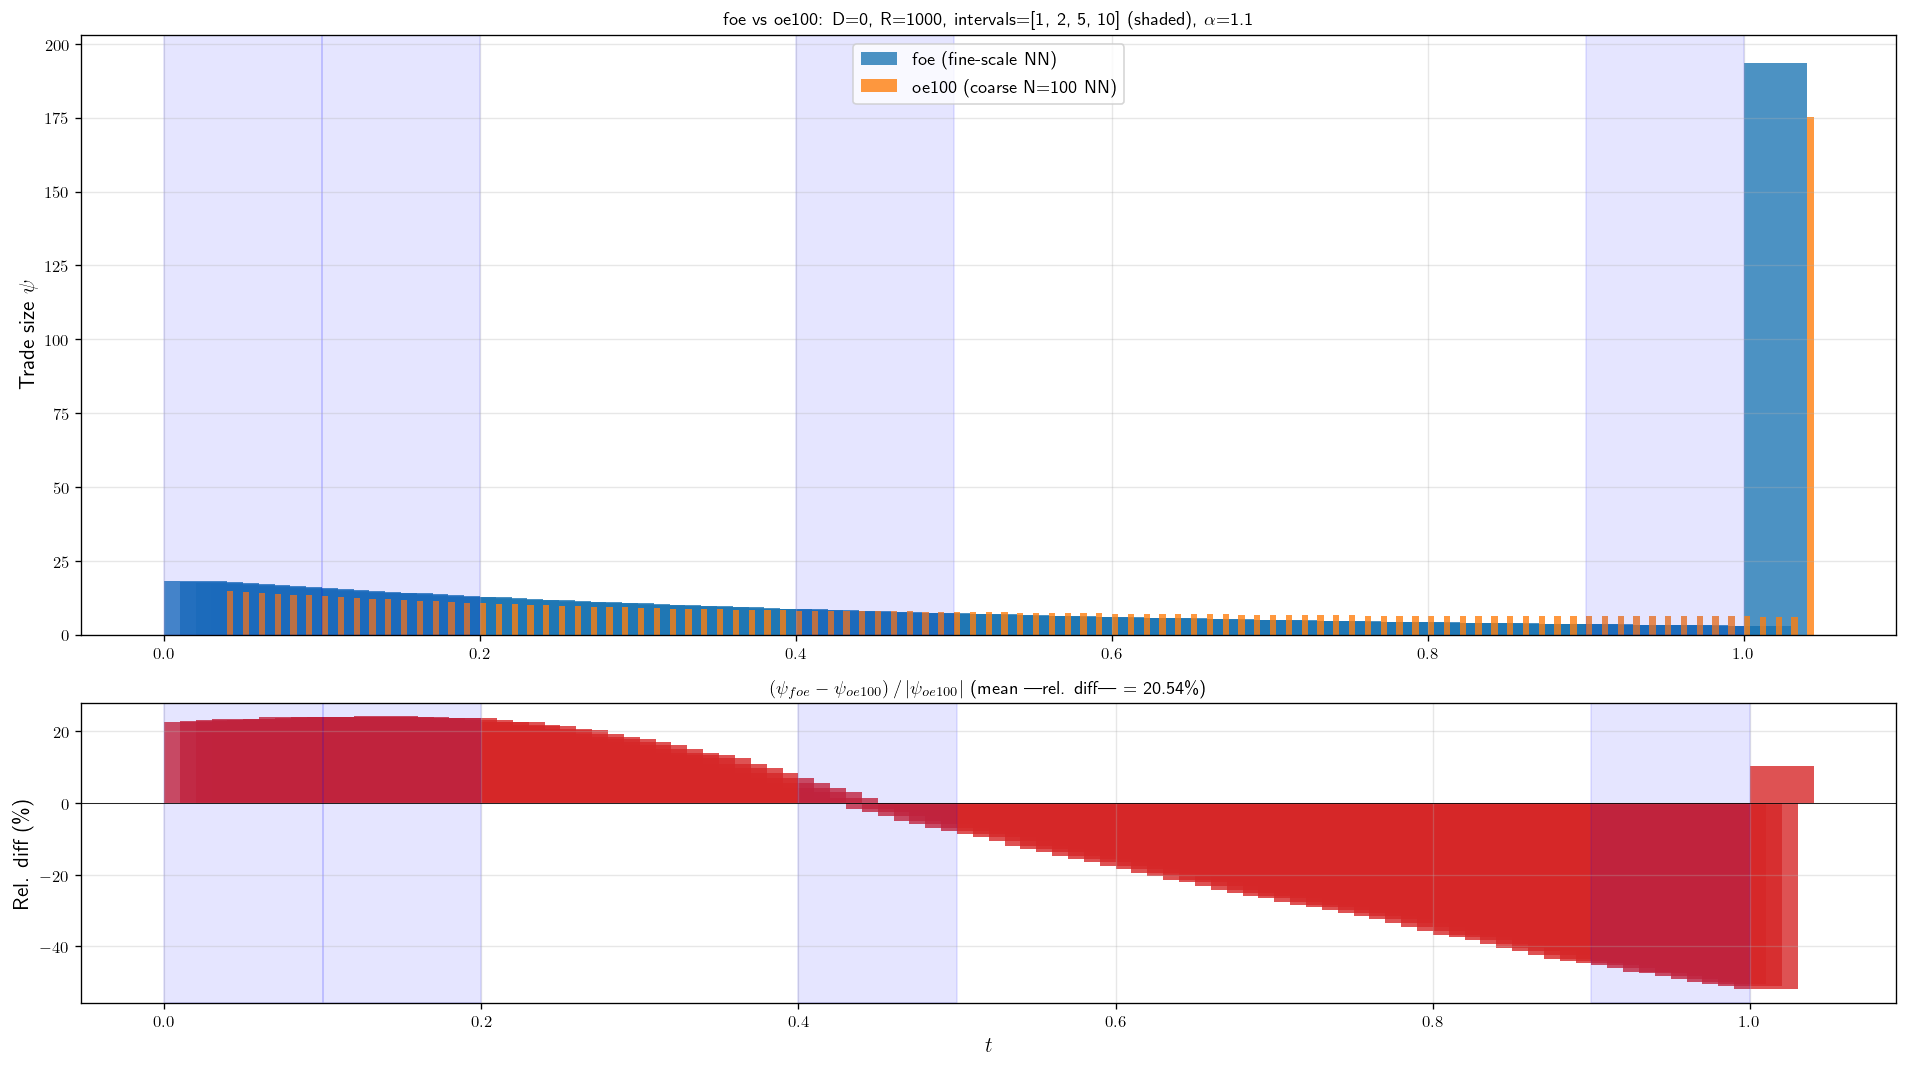

In [20]:
# Compare foe (fine) vs oe100 (coarse N=100) trade sizes from D=0, R=X0
# Pre-generate a shared kappa/rho path at fine resolution so both rollouts see the same realization
torch.manual_seed(42)
kap0, rho0 = oe100.kappa, oe100.rho
N_fine_total = foe.N_total  # 100 fine steps
delta_fine = foe.delta
sqrt_df = np.sqrt(delta_fine)
shared_kap = torch.zeros(N_fine_total + 1)
shared_rho = torch.zeros(N_fine_total + 1)
shared_kap[0] = kap0
shared_rho[0] = rho0
for n in range(N_fine_total):
    shared_kap[n+1] = max(1e-4, shared_kap[n].item()
        + foe.theta_kappa * (foe.kappa - shared_kap[n].item()) * delta_fine
        + foe.sigma_kappa * sqrt_df * torch.randn(1).item())
    shared_rho[n+1] = max(1e-4, shared_rho[n].item()
        + foe.theta_rho * (foe.rho - shared_rho[n].item()) * delta_fine
        + foe.sigma_rho * sqrt_df * torch.randn(1).item())

# Roll out oe100 trajectory using shared path
# oe100 has N=100 coarse steps with delta = foe.delta, so fine step n maps 1:1
oe100.kappa_paths = shared_kap.unsqueeze(0)  # (1, 101)
oe100.rho_paths = shared_rho.unsqueeze(0)
u_oe100 = torch.tensor([[0.0, 0.0, float(oe100.X0), shared_kap[0].item(), shared_rho[0].item()]])
psi_oe100, t_oe100 = [], []
for n in range(oe100.N):
    t_oe100.append(n * oe100.delta)
    with torch.no_grad():
        psi = oe100.trade_size(u_oe100).squeeze().item()
    psi_oe100.append(psi)
    u_oe100 = oe100.update(u_oe100, torch.tensor([psi]))
t_oe100.append(oe100.N * oe100.delta)
psi_oe100.append(u_oe100[0, 2].item())

# Roll out foe trajectory using the same shared path
u_foe = torch.tensor([[0.0, 0.0, float(foe.X0), shared_kap[0].item(), shared_rho[0].item()]])
psi_foe, t_foe = [], []
for n in range(foe.N_total):
    t_foe.append(n * foe.delta)
    with torch.no_grad():
        psi = foe.trade_size(u_foe).squeeze().item()
    psi_foe.append(psi)
    # Use foe.update but override kappa/rho with the shared path
    u_next = foe.update(u_foe, torch.tensor([psi]))
    u_next[0, 3] = shared_kap[n + 1]
    u_next[0, 4] = shared_rho[n + 1]
    u_foe = u_next
t_foe.append(foe.N_total * foe.delta)
psi_foe.append(u_foe[0, 2].item())

t_oe100 = np.array(t_oe100)
t_foe = np.array(t_foe)
psi_oe100 = np.array(psi_oe100)
psi_foe = np.array(psi_foe)


# Relative difference: (foe - oe100) / oe100 at each fine step
# oe100 and foe have the same time grid (both 100 fine steps + terminal)
rel_diff = np.where(np.abs(psi_oe100) > 1e-8,
                    (psi_foe - psi_oe100) / np.abs(psi_oe100), 0.0)
overall_rel_err = np.mean(np.abs(psi_foe - psi_oe100)) / np.mean(np.abs(psi_oe100)) * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 9), dpi=120,
                                gridspec_kw={'height_ratios': [2, 1]})

# Top: trade sizes
ax1.bar(t_foe, psi_foe, width=bar_w, align='edge', alpha=0.8, label='foe (fine-scale NN)')
ax1.bar(t_oe100 + bar_w, psi_oe100, width=oe100.delta * 0.4, align='edge', alpha=0.8, label='oe100 (coarse N=100 NN)')
intervals_sorted = sorted(foe.intervals)
for n_int in intervals_sorted:
    t_s = (n_int - 1) * oe.delta
    t_e = n_int * oe.delta
    ax1.axvspan(t_s, t_e, alpha=0.10, color='blue')
ax1.set_ylabel(r'Trade size $\psi$', fontsize=13)
ax1.set_title(f'foe vs oe100: D=0, R={int(foe.X0)}, intervals={intervals_sorted} (shaded), '
              f'$\\alpha$={oe.alpha}', fontsize=11)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Bottom: relative difference
ax2.bar(t_foe, rel_diff * 100, width=bar_w, align='edge', alpha=0.8, color='tab:red')
for n_int in intervals_sorted:
    t_s = (n_int - 1) * oe.delta
    t_e = n_int * oe.delta
    ax2.axvspan(t_s, t_e, alpha=0.10, color='blue')
ax2.axhline(0, color='k', lw=0.5)
ax2.set_xlabel(r'$t$', fontsize=13)
ax2.set_ylabel(r'Rel. diff (\%)', fontsize=13)
ax2.set_title(f'$(\\psi_{{foe}} - \\psi_{{oe100}}) \\,/\\, |\\psi_{{oe100}}|$   '
              f'(mean |rel. diff| = {overall_rel_err:.2f}%%)', fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(f'v7_alpha{oe.alpha}_bar_chart_foe_vs_oe100.png', dpi=150, bbox_inches='tight')
plt.show()
